Project Overview: Fraud Detection
A Fraud Detection System is an automated machine learning pipeline built to identify and prevent deceptive, unauthorized, or illegal activities within financial networks.

Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the dataset directly from your Colab files
df = pd.read_csv('/content/creditcard.csv')

# Preview the first few rows
df.head()

/tmp/ipykernel_865/1230760960.py:12: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/creditcard.csv')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


Check Class Imbalance

Class Distribution (0 = Legit, 1 = Fraud):
Class
0.0    33656
1.0      103
Name: count, dtype: int64

Percentage Breakdown:
Class
0.0    99.694896
1.0     0.305104
Name: proportion, dtype: float64


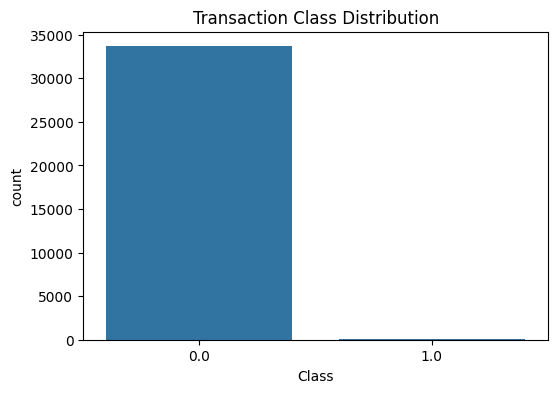

In [ ]:
# Check the distribution of the target variable
print("Class Distribution (0 = Legit, 1 = Fraud):")
print(df['Class'].value_counts())
print("\nPercentage Breakdown:")
print(df['Class'].value_counts(normalize=True) * 100)

# Quick visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution')
plt.show()

Preprocess and Split Data

In [ ]:
# 1. Check if there are any missing values (Optional, just to see)
missing_counts = df.isnull().sum().sum()
if missing_counts > 0:
    print(f"Found {missing_counts} missing values. Cleaning them up...")
    # Drop rows that contain any missing values
    df = df.dropna()

# 2. Scale transaction amounts
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 3. Drop the original unscaled Amount and Time columns
X = df.drop(['Class', 'Time', 'Amount'], axis=1)
y = df['Class']

# 4. Now perform the Stratified split safely
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data cleaned and split successfully!")
print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Found 9 missing values. Cleaning them up...
Data cleaned and split successfully!
Training shapes: (27007, 29), Testing shapes: (6752, 29)


rain Model with Class Balancing

In [ ]:
# Initialize and train Logistic Regression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

Evaluate the Results

### Classification Report ###
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      6731
         1.0       0.18      0.81      0.30        21

    accuracy                           0.99      6752
   macro avg       0.59      0.90      0.65      6752
weighted avg       1.00      0.99      0.99      6752

ROC-AUC Score: 0.9340



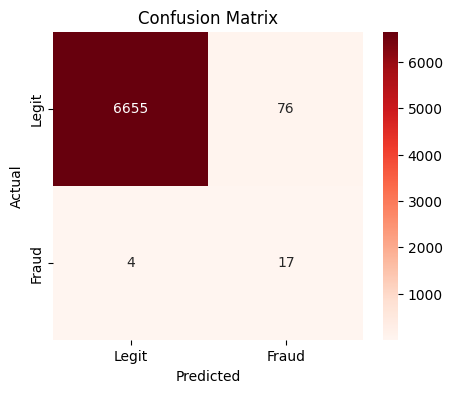

In [ ]:
# Print performance summary
print("### Classification Report ###")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")

# Plot Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Simulate Real-Time Threshold Monitoring & Scalability

--- Performance at Default Threshold (0.50) ---
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      6731
         1.0       0.18      0.81      0.30        21

    accuracy                           0.99      6752
   macro avg       0.59      0.90      0.65      6752
weighted avg       1.00      0.99      0.99      6752


--- Performance at Aggressive Real-Time Threshold (0.20) ---
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99      6731
         1.0       0.09      0.81      0.16        21

    accuracy                           0.97      6752
   macro avg       0.54      0.89      0.57      6752
weighted avg       1.00      0.97      0.98      6752



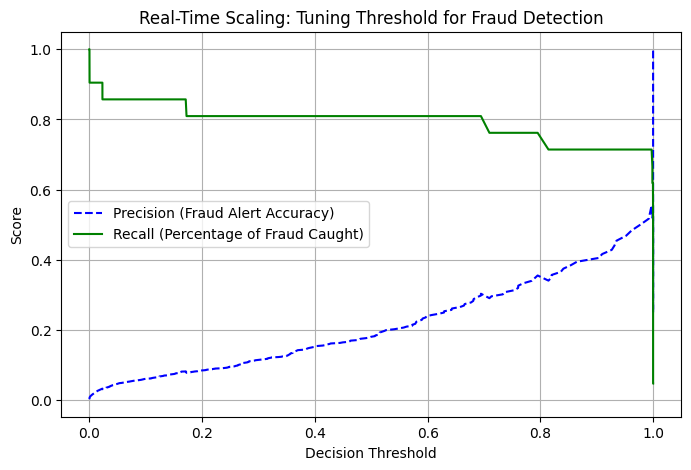

In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report
import matplotlib.pyplot as plt

# 1. Get the raw probability scores for the positive class (Fraud)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# 2. Define a custom threshold (e.g., lower it to 0.20 to catch more fraud)
custom_threshold = 0.20
y_pred_custom = (y_pred_prob >= custom_threshold).astype(int)

# 3. Compare the original performance vs the real-time adjusted performance
print(f"--- Performance at Default Threshold (0.50) ---")
print(classification_report(y_test, y_pred))

print(f"\n--- Performance at Aggressive Real-Time Threshold ({custom_threshold:.2f}) ---")
print(classification_report(y_test, y_pred_custom))

# 4. Plot the Precision-Recall curve to visualize the optimal balance for scaling
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Fraud Alert Accuracy)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Percentage of Fraud Caught)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Real-Time Scaling: Tuning Threshold for Fraud Detection')
plt.legend(loc='best')
plt.grid(True)
plt.show()

short explanation by pipeline

--- Loading Data ---
Found and dropped 18 missing values.
--- Preprocessing Features ---
--- Training Balanced Model ---

### METRICS AT DEFAULT THRESHOLD (0.50) ###
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     18593
         1.0       0.10      0.93      0.17        43

    accuracy                           0.98     18636
   macro avg       0.55      0.95      0.58     18636
weighted avg       1.00      0.98      0.99     18636

ROC-AUC Score: 0.9758

### METRICS AT CUSTOM REAL-TIME THRESHOLD (0.20) ###
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97     18593
         1.0       0.04      0.95      0.07        43

    accuracy                           0.94     18636
   macro avg       0.52      0.95      0.52     18636
weighted avg       1.00      0.94      0.97     18636



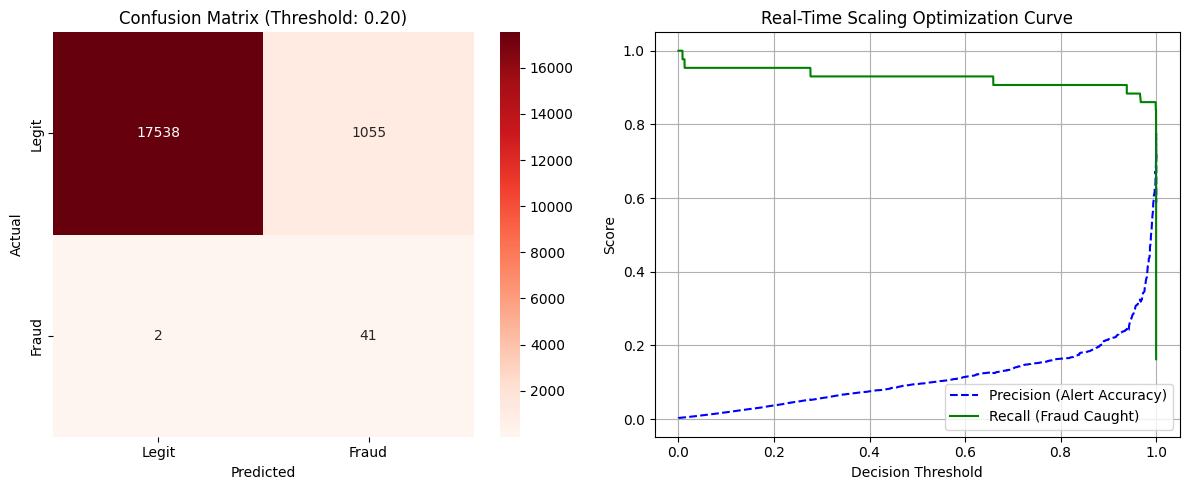

--- Pipeline Execution Complete! ---


In [ ]:
# ==========================================
# MASTER FRAUD DETECTION PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

# --- STEP 1: LOAD & CLEAN DATA ---
print("--- Loading Data ---")
filepath = '/content/creditcard.csv'  # Update this path for future datasets
df = pd.read_csv(filepath)

# Handle missing data if any exist
missing_counts = df.isnull().sum().sum()
if missing_counts > 0:
    print(f"Found and dropped {missing_counts} missing values.")
    df = df.dropna()

# --- STEP 2: FEATURE ENGINEERING ---
print("--- Preprocessing Features ---")
# Scale highly variable transaction amounts
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Isolate features (X) and target class (y)
# Drop original unscaled amount and unneeded metadata like 'Time'
X = df.drop(['Class', 'Time', 'Amount'], axis=1, errors='ignore')
y = df['Class']

# Stratified split to maintain exact fraud percentage in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- STEP 3: TRAIN ML MODEL WITH CLASS BALANCE ---
print("--- Training Balanced Model ---")
# Using class_weight='balanced' handles severe anomalies/imbalances automatically
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# --- STEP 4: EVALUATE BASELINE (0.50 Threshold) ---
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n### METRICS AT DEFAULT THRESHOLD (0.50) ###")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")

# --- STEP 5: REAL-TIME THRESHOLD TUNING (Simulation) ---
# Lowering threshold to catch more fraud early (e.g., 20% risk certainty)
custom_threshold = 0.20
y_pred_custom = (y_pred_prob >= custom_threshold).astype(int)

print(f"### METRICS AT CUSTOM REAL-TIME THRESHOLD ({custom_threshold:.2f}) ###")
print(classification_report(y_test, y_pred_custom))

# --- STEP 6: VISUALIZATION ---
# Plot 1: Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (Threshold: {custom_threshold:.2f})')

# Plot 2: Precision-Recall Curve for Scalability Scaling
plt.subplot(1, 2, 2)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Alert Accuracy)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Fraud Caught)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Real-Time Scaling Optimization Curve')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()

print("--- Pipeline Execution Complete! ---")